# 2D Poisson Equation — Strong Formulation with `ProblemStrong`

Solve the **Poisson equation** on the unit square using the **strong (collocation) formulation**:

$$-\nabla^2 u = f \quad \text{in } \Omega = [0,1]^2$$

**Analytical solution (used for validation):**

$$u^*(x,y) = \sin(\pi x)\sin(\pi y), \qquad f(x,y) = 2\pi^2\sin(\pi x)\sin(\pi y)$$

**Boundary conditions:** $u = 0$ on all four sides (Dirichlet).


In [1]:
import pinns
from pinns import DomainMesh, ProblemStrong, create_model, Trainer, derivative
import pinns.meshes as meshes

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import jax.numpy as jnp


## 1. Domain

Use the built-in `pinns.meshes.square()` helper — no manual pygmsh setup required.
It returns `(verts, faces)` which `DomainMesh` accepts directly as a tuple.


In [2]:
mesh = meshes.square(x_max=1.0, y_max=1.0, mesh_size=0.05)
print(f"Mesh: {len(mesh[0])} vertices, {len(mesh[1])} triangles")

Mesh: 568 vertices, 1054 triangles


In [3]:
tol = 1e-10

domain = DomainMesh(mesh)

domain.add_boundary(lambda v: v[:, 1] < tol,       name="bottom")   # y = 0
domain.add_boundary(lambda v: v[:, 0] > 1.0 - tol, name="right")    # x = 1
domain.add_boundary(lambda v: v[:, 1] > 1.0 - tol, name="top")      # y = 1
domain.add_boundary(lambda v: v[:, 0] < tol,       name="left")     # x = 0

print(domain)


DomainMesh(2D, n_nodes=568, n_conditions=0, inner_regions=[], boundary_regions=['bottom', 'right', 'top', 'left'])


<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

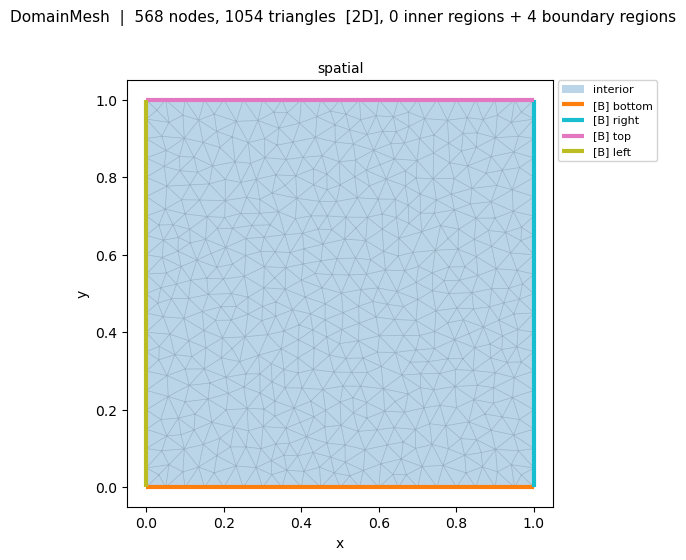

In [4]:
domain.plot(region="all", boundary="custom", backend="matplotlib")

## 2. Define the ProblemStrong

The PDE residual for the Poisson equation is:

$$\mathcal{R} = -\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right) - f(x, y) = 0$$

with $f = 2\pi^2 \sin(\pi x)\sin(\pi y)$.

Residual functions receive:
- **X** — collocation points, shape $(N, 2)$
- **U** — network output, shape $(N, 1)$
- **params** — dict with `"fixed"` constants
- **derivative** — `derivative(U, X, output_col, orders)`


In [5]:
problem = ProblemStrong(
    domain=domain,
    output_names=["u"],
)

def poisson_residual(X, U, params, derivative):
    u = U[:, 0:1]
    u_xx = derivative(u, X, 0, (0, 0))   # ∂²u/∂x²
    u_yy = derivative(u, X, 0, (1, 1))   # ∂²u/∂y²
    f = 2.0 * jnp.pi**2 * jnp.sin(jnp.pi * X[:, 0:1]) * jnp.sin(jnp.pi * X[:, 1:2])
    return -(u_xx + u_yy) - f

problem.add_inner(poisson_residual, name="pde")

problem.add_dirichlet(0.0, name="bottom", region="bottom")
problem.add_dirichlet(0.0, name="right",  region="right")
problem.add_dirichlet(0.0, name="top",    region="top")
problem.add_dirichlet(0.0, name="left",   region="left")

# Analytical solution for error evaluation
trainer.add_solution(
    lambda X, params: np.sin(np.pi * X[:, 0]) * np.sin(np.pi * X[:, 1])
)

print(problem)

ProblemStrong(domain=DomainMesh, n_dims=2, n_outputs=1, inner=1, boundary=4, initial=0, params=[], trainable=[])


## 3. Build the network


In [6]:
network = create_model(
    domain,
    output_dim=1,
    hidden_dims=(128, 128, 128),
    # core=pinns.PirateNet(128, 3),
    activation="tanh",
)

print(network)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=2, n_context=0, context_scaled=False)
  [FNN_1] FNN(layer_sizes=[2, 128, 128, 128, 1])


# 4. Training

Starting training for 10000 epochs (JIT-compiled)...


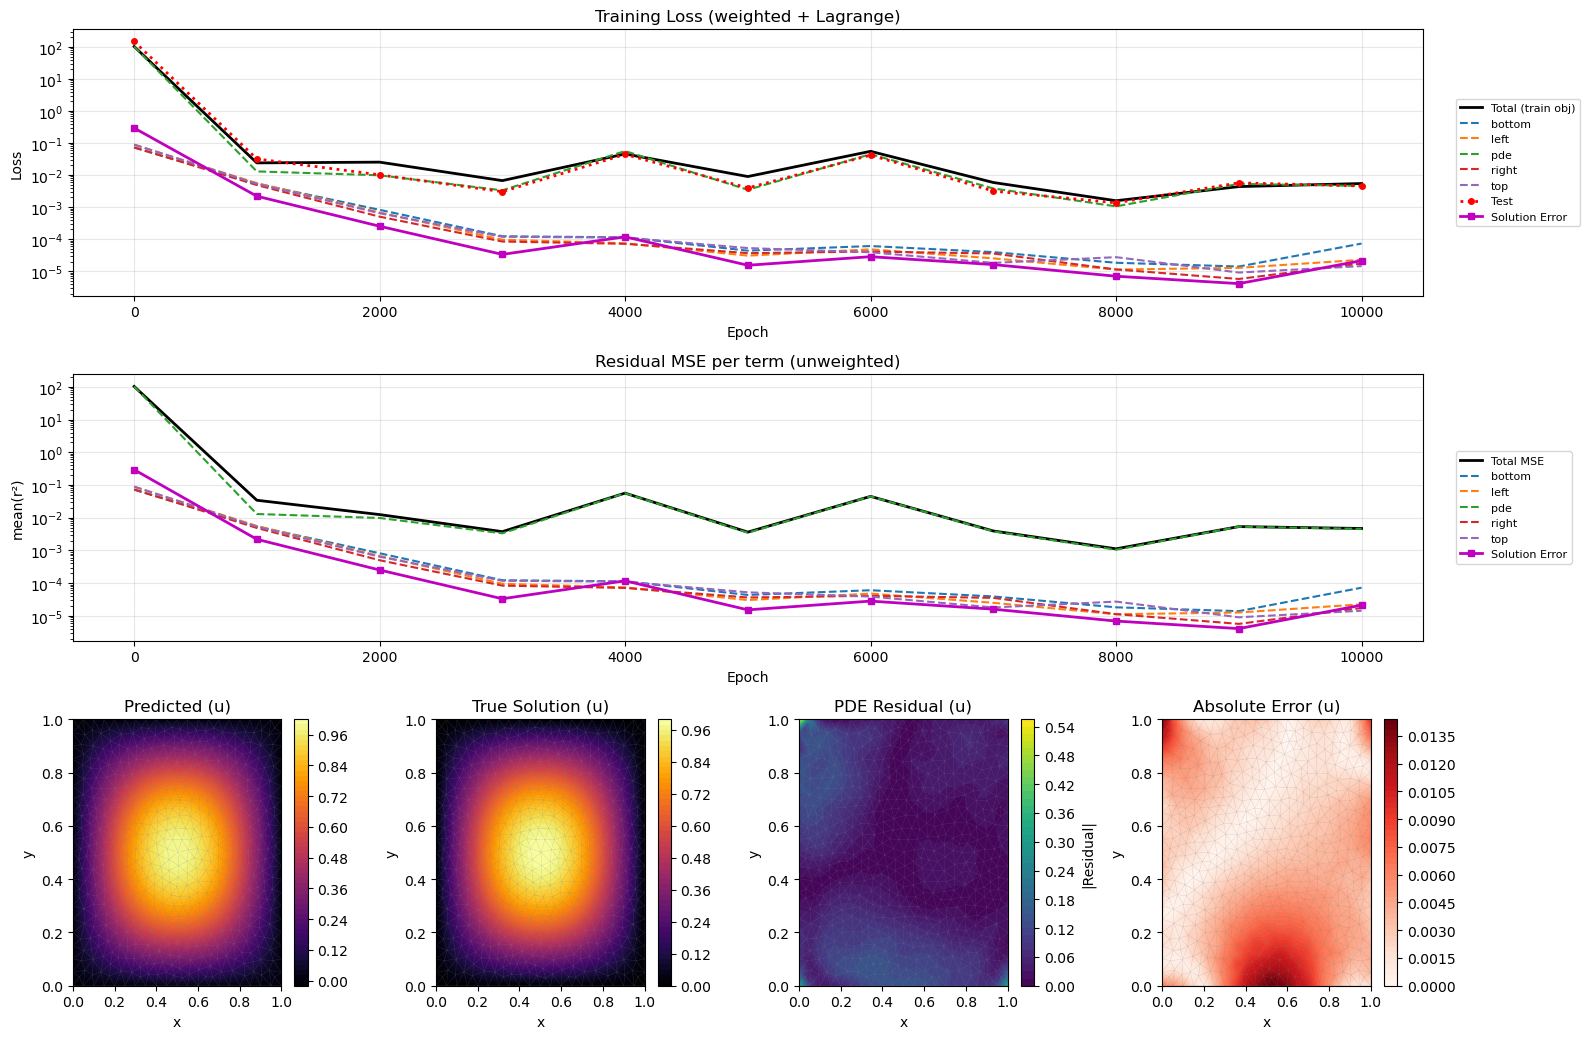

Epoch 0/10000 | Loss: 1.02e+02 | MSE: 1.02e+02 | Terms: [bottom: 7.18e-02, left: 8.78e-02, pde: 1.02e+02, right: 7.29e-02, top: 8.93e-02] | Test Loss: 1.48e+02 | Error: 2.93e-01 | Time: 0.0s
Epoch 1000/10000 | Loss: 2.39e-02 | MSE: 3.41e-02 | Terms: [bottom: 5.38e-03, left: 5.60e-03, pde: 1.30e-02, right: 4.87e-03, top: 5.32e-03] | Test Loss: 3.19e-02 | Error: 2.19e-03 | Time: 4.0s
Epoch 2000/10000 | Loss: 2.52e-02 | MSE: 1.25e-02 | Terms: [bottom: 8.20e-04, left: 6.80e-04, pde: 9.81e-03, right: 5.02e-04, top: 6.43e-04] | Test Loss: 1.01e-02 | Error: 2.53e-04 | Time: 4.8s
Epoch 3000/10000 | Loss: 6.69e-03 | MSE: 3.75e-03 | Terms: [bottom: 1.23e-04, left: 9.57e-05, pde: 3.33e-03, right: 8.41e-05, top: 1.18e-04] | Test Loss: 3.02e-03 | Error: 3.33e-05 | Time: 5.6s
Epoch 4000/10000 | Loss: 4.55e-02 | MSE: 5.64e-02 | Terms: [bottom: 1.14e-04, left: 7.43e-05, pde: 5.60e-02, right: 7.13e-05, top: 1.11e-04] | Test Loss: 4.41e-02 | Error: 1.18e-04 | Time: 6.3s
Epoch 5000/10000 | Loss: 8.97e-03

In [7]:
trainer = Trainer(network, problem=problem)

trainer.compile(
    problem={
        "pde" :   {"train": 500, "test": 50, "weight": 1.0},
        "bottom": {"train": 100, "test": 50, "weight": 1.0},
        "right":  {"train": 100, "test": 50, "weight": 1.0},
        "top":    {"train": 100, "test": 50, "weight": 1.0},
        "left":   {"train": 100, "test": 50, "weight": 1.0},
    },
    epochs=10000,
    print_each=1000,
    # show=None
)

trainer.train()